# 🌸 Iris Flower Classification with Machine Learning

This notebook trains and evaluates multiple ML models to classify Iris flowers into three species: **Setosa**, **Versicolor**, and **Virginica** based on sepal and petal measurements.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import warnings
warnings.filterwarnings("ignore")
print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load & Inspect Data

In [2]:
df = pd.read_csv("Iris.csv")

print(f"Shape       : {df.shape}")
print(f"\nClass Distribution:\n{df['Species'].value_counts()}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
df.head()

Shape       : (150, 6)

Class Distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Missing Values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


### Descriptive Statistics

In [3]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


## 3. Preprocessing

In [4]:
# Drop the Id column
df.drop(columns=["Id"], inplace=True)

# Encode target labels
le = LabelEncoder()
df["Species_enc"] = le.fit_transform(df["Species"])
print(f"Label Encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Features and target
X = df[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]]
y = df["Species_enc"]

# Train/Test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")

# Feature scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Label Encoding: {'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}
Train size: 120  |  Test size: 30


## 4. Train Multiple Models & Compare (5-Fold CV)

In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree"      : DecisionTreeClassifier(random_state=42),
    "Random Forest"      : RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM"                : SVC(kernel="rbf", C=1.0, random_state=42),
    "KNN (k=5)"          : KNeighborsClassifier(n_neighbors=5),
}
scale_needed = {"Logistic Regression", "SVM", "KNN (k=5)"}

results = {}
print(f"{'Model':<25}  {'CV Accuracy':>12}  {'Std Dev':>8}")
print("-" * 50)
for name, model in models.items():
    Xtr = X_train_sc if name in scale_needed else X_train
    cv_scores = cross_val_score(model, Xtr, y_train, cv=5, scoring="accuracy")
    results[name] = cv_scores
    print(f"{name:<25}  {cv_scores.mean():>12.4f}  {cv_scores.std():>8.4f}")

Model                       CV Accuracy   Std Dev
--------------------------------------------------
Logistic Regression              0.9583    0.0264
Decision Tree                    0.9417    0.0204
Random Forest                    0.9500    0.0167
SVM                              0.9667    0.0312
KNN (k=5)                        0.9667    0.0312


## 5. Evaluate Best Model on Test Set (Random Forest)

In [6]:
best_name  = "Random Forest"
best_model = models[best_name]
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print(f"Test Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Test Accuracy : 0.9000

Classification Report:

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30



## 6. Visualisations

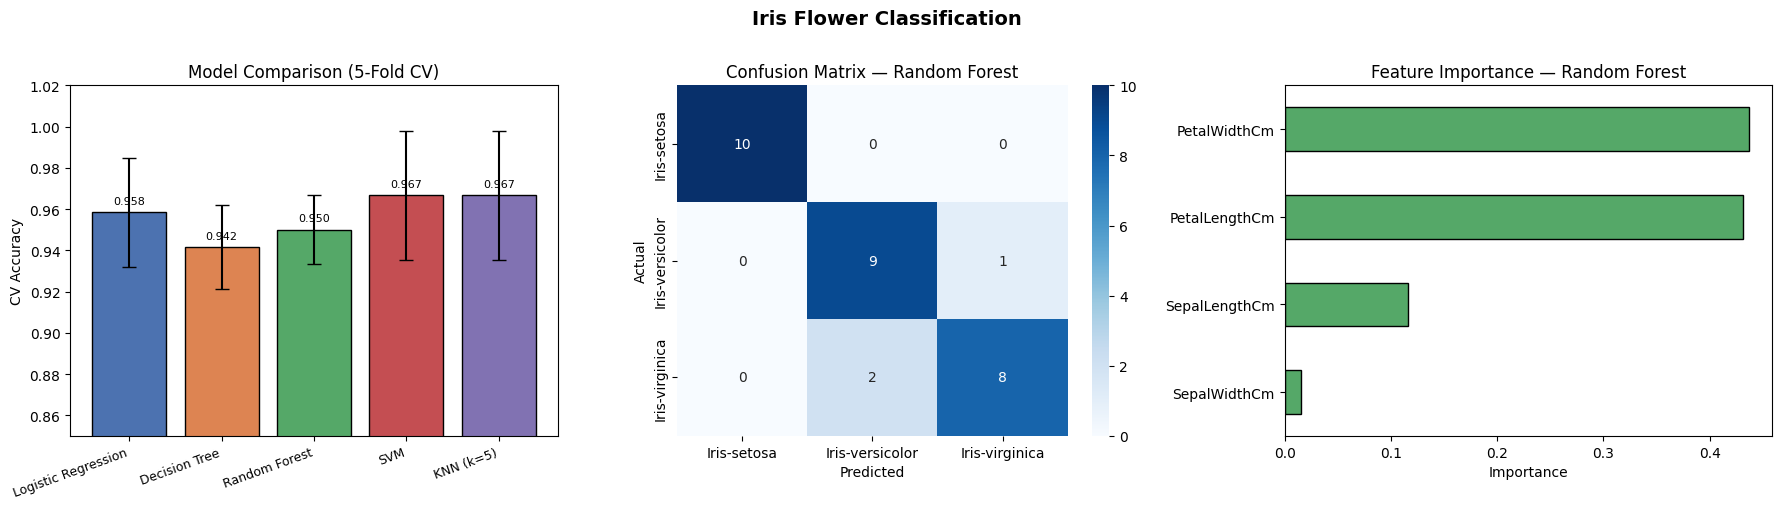

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- CV Accuracy Bar Chart ---
ax = axes[0]
names  = list(results.keys())
means  = [v.mean() for v in results.values()]
stds   = [v.std()  for v in results.values()]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]
bars   = ax.bar(names, means, yerr=stds, color=colors, capsize=5, edgecolor="black")
ax.set_ylim(0.85, 1.02)
ax.set_ylabel("CV Accuracy")
ax.set_title("Model Comparison (5-Fold CV)")
ax.set_xticklabels(names, rotation=20, ha="right", fontsize=9)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.003,
            f"{m:.3f}", ha="center", va="bottom", fontsize=8)

# --- Confusion Matrix ---
ax = axes[1]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title(f"Confusion Matrix — {best_name}")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

# --- Feature Importance ---
ax = axes[2]
feat_imp = pd.Series(best_model.feature_importances_, index=X.columns).sort_values()
feat_imp.plot(kind="barh", color="#55A868", edgecolor="black", ax=ax)
ax.set_title(f"Feature Importance — {best_name}")
ax.set_xlabel("Importance")

plt.suptitle("Iris Flower Classification", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("iris_results.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Predict on New Samples

In [8]:
new_samples = pd.DataFrame({
    "SepalLengthCm": [5.1, 6.3, 7.2],
    "SepalWidthCm" : [3.5, 2.9, 3.0],
    "PetalLengthCm": [1.4, 5.6, 5.8],
    "PetalWidthCm" : [0.2, 1.8, 1.6],
})

preds = best_model.predict(new_samples)
for i, (_, row) in enumerate(new_samples.iterrows()):
    species = le.inverse_transform([preds[i]])[0]
    print(f"Sample {i+1}: SepalL={row['SepalLengthCm']}, SepalW={row['SepalWidthCm']}, "
          f"PetalL={row['PetalLengthCm']}, PetalW={row['PetalWidthCm']}  →  {species}")

Sample 1: SepalL=5.1, SepalW=3.5, PetalL=1.4, PetalW=0.2  →  Iris-setosa
Sample 2: SepalL=6.3, SepalW=2.9, PetalL=5.6, PetalW=1.8  →  Iris-virginica
Sample 3: SepalL=7.2, SepalW=3.0, PetalL=5.8, PetalW=1.6  →  Iris-virginica
